# Entrenamiento del Modelo — UI-PRMD

**Asistente de Rehabilitación Física con IA**

Este notebook entrena un `RandomForestClassifier` con `class_weight='balanced'` sobre  
el dataset **UI-PRMD** (University of Idaho Physical Rehabilitation Movement Data),  
enfocado en los ejercicios:

| ID | Ejercicio |
|----|----------|
| m07 | Standing Shoulder Internal/External Rotation |
| m09 | Standing Shoulder Abduction |

**Objetivo principal:** maximizar **recall de ejecuciones incorrectas** (clase 1).  
El modelo resultante se exporta en formato `.pkl` para ser consumido por la API/app móvil.

---

### Fuentes de datos empleadas
```
Movements/                   → secuencias CORRECTAS (m_ss_positions.txt / _angles.txt)
Incorrect Movements/         → secuencias INCORRECTAS (_positions_inc.txt / _angles_inc.txt)
Segmented Movements/         → repeticiones segmentadas CORRECTAS (_e##_positions.txt)
Incorrect Segmented Movements/ → repeticiones segmentadas INCORRECTAS
```
Sensor: **Kinect** | Sub-carpetas: **Positions** (XYZ de 22 joints, 66 cols) y  
**Angles** (66 ángulos articulares).

### Pipeline general
1. Cargar archivos → serie temporal por secuencia  
2. Extraer features estadísticas por secuencia  
3. Validación cruzada Leave-One-Subject-Out (LOSO)  
4. Ajuste del umbral de decisión para maximizar recall  
5. Exportar modelo final entrenado con todos los datos  
6. Función de inferencia para JSON del móvil  

## 0 · Instalación de dependencias

In [1]:
# Ejecuta esta celda solo la primera vez
%pip install -q numpy pandas scikit-learn imbalanced-learn matplotlib seaborn joblib tqdm

Note: you may need to restart the kernel to use updated packages.


## 1 · Importaciones y configuración global

In [2]:
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score, f1_score,
    precision_recall_curve, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')

# ── Semilla de reproducibilidad ──────────────────────────────────────────
RANDOM_STATE = 42

# ── Raíz del workspace (ajusta si mueves el notebook) ─────────────────────
BASE_DIR = Path('.').resolve()
print(f'BASE_DIR → {BASE_DIR}')

BASE_DIR → C:\Users\marco\notebooks\modelo_rehabilitacion


## 2 · Definición de ejercicios objetivo

El dataset UI-PRMD contiene 10 ejercicios (`m01`–`m10`), 10 sujetos (`s01`–`s10`).  
En esta iteración priorizamos:
- **m07** → Standing Shoulder Internal / External Rotation  
- **m09** → Standing Shoulder Abduction

Cambia `MOVEMENT_IDS` para incluir o excluir ejercicios en el entrenamiento.

In [3]:
# Ejercicios a entrenar (pueden ser varios o todos: range(1, 11))
MOVEMENT_IDS = [7, 9]          # m07 y m09

# Fuente de datos: 'Angles', 'Positions' o 'Both'
DATA_SOURCE = 'Angles'         # Recomendado: ángulos articulares

MOVEMENT_NAMES = {
    1:  'Standing Elbow Flexion',
    2:  'Standing Shoulder Forward Elevation',
    3:  'Standing Hip Abduction',
    4:  'Sitting Knee Extension',
    5:  'Standing Hip Extension',
    6:  'Sitting Shoulder Forward Elevation',
    7:  'Standing Shoulder Internal/External Rotation',
    8:  'Lying Wrist Circumduction',
    9:  'Standing Shoulder Abduction',
    10: 'Standing Elbow Extension',
}

print('Ejercicios seleccionados:')
for mid in MOVEMENT_IDS:
    print(f'  m{mid:02d} → {MOVEMENT_NAMES[mid]}')

Ejercicios seleccionados:
  m07 → Standing Shoulder Internal/External Rotation
  m09 → Standing Shoulder Abduction


## 3 · Carga de datos desde los archivos UI-PRMD

### 3.1 · Funciones de I/O

In [4]:
def _load_txt(filepath: Path) -> np.ndarray | None:
    """Carga un archivo .txt del dataset UI-PRMD como numpy array (frames × cols).
    Soporta separadores por espacios o por coma.
    Retorna None si el archivo está vacío o tiene un error.
    """
    try:
        # Intenta con coma primero (archivos segmentados) y luego espacio
        for sep in (',', None):           # None → whitespace split
            try:
                arr = np.loadtxt(filepath, delimiter=sep)
                if arr.ndim == 1:
                    arr = arr.reshape(1, -1)
                if arr.shape[0] > 0 and arr.shape[1] > 0:
                    return arr
            except ValueError:
                continue
        return None
    except Exception:
        return None


def _parse_movement_id(filename: str) -> int:
    """Extrae el número de movimiento desde el nombre del archivo."""
    m = re.search(r'm(\d{2})', filename)
    return int(m.group(1)) if m else -1


def _parse_subject_id(filename: str) -> int:
    """Extrae el ID de sujeto desde el nombre del archivo."""
    m = re.search(r's(\d{2})', filename)
    return int(m.group(1)) if m else -1

### 3.2 · Extracción de features estadísticas por secuencia

Cada secuencia (archivo) → vector de features compacto.

Features extraídas por columna:
`mean, std, min, max, range, median, iqr, rms, skew, kurtosis, sum_abs_diff (MAD temporalmente)`

In [5]:
from scipy import stats as sp_stats

def extract_features(arr: np.ndarray) -> np.ndarray:
    """Extrae features estadísticas de una secuencia temporal (frames × cols).
    
    Retorna un vector 1D con:
    [mean, std, min, max, ptp, median, iqr, rms, skew, kurtosis, mad] por columna.
    """
    feats = []
    for col in arr.T:               # Itera columna a columna
        feats.append(np.mean(col))
        feats.append(np.std(col))
        feats.append(np.min(col))
        feats.append(np.max(col))
        feats.append(np.ptp(col))   # peak-to-peak = range
        feats.append(np.median(col))
        q75, q25 = np.percentile(col, [75, 25])
        feats.append(q75 - q25)     # IQR
        feats.append(np.sqrt(np.mean(col**2)))  # RMS
        feats.append(float(sp_stats.skew(col)))
        feats.append(float(sp_stats.kurtosis(col)))
        # Mean absolute difference entre frames consecutivos
        feats.append(np.mean(np.abs(np.diff(col))))
    return np.array(feats, dtype=np.float32)

N_FEATURES_PER_COL = 11
N_COLS_KINECT = 66
EXPECTED_N_FEATURES = N_FEATURES_PER_COL * N_COLS_KINECT
print(f'Dimensión esperada del vector de features: {EXPECTED_N_FEATURES}')

Dimensión esperada del vector de features: 726


### 3.3 · Carga completa del dataset

In [6]:
from typing import Literal
from tqdm.auto import tqdm

def load_dataset(
    base_dir: Path,
    movement_ids: list[int],
    source: Literal['Angles', 'Positions', 'Both'] = 'Angles',
    use_segmented: bool = True,
) -> pd.DataFrame:
    """Carga todos los archivos del dataset UI-PRMD para los movimientos indicados.

    Parámetros
    ----------
    base_dir     : raíz del workspace
    movement_ids : lista de IDs (e.g. [7, 9])
    source       : 'Angles' | 'Positions' | 'Both'
    use_segmented: Si True, usa los archivos *Segmented* (una rep por archivo).
                   Si False, usa los archivos completos (toda la sesión).

    Retorna
    -------
    DataFrame con columnas: movement_id, subject_id, label, features (como columnas feat_0 … feat_N)
    """

    # Mapeo de carpetas según los 4 splits del dataset
    splits = [
        # (folder_name, label, segmented)
        ('Segmented Movements',           0, True),
        ('Incorrect Segmented Movements', 1, True),
        ('Movements',                     0, False),
        ('Incorrect Movements',           1, False),
    ]

    records = []

    for folder_name, label, is_segmented in splits:
        if use_segmented != is_segmented:
            continue

        # Estructura anidada: folder_name/folder_name/Kinect/(Angles|Positions)
        sub_sources = ['Angles'] if source == 'Angles' else \
                      ['Positions'] if source == 'Positions' else \
                      ['Angles', 'Positions']

        for sub_src in sub_sources:
            data_dir = base_dir / folder_name / folder_name / 'Kinect' / sub_src
            if not data_dir.exists():
                print(f'  ⚠ Directorio no encontrado: {data_dir}')
                continue

            txt_files = sorted(data_dir.glob('*.txt'))
            print(f'  📂 {folder_name}/{sub_src}: {len(txt_files)} archivos')

            for fp in tqdm(txt_files, desc=f'{folder_name[:20]}/{sub_src}', leave=False):
                mid = _parse_movement_id(fp.name)
                sid = _parse_subject_id(fp.name)

                if mid not in movement_ids:
                    continue

                arr = _load_txt(fp)
                if arr is None or arr.shape[0] < 2:
                    continue

                fv = extract_features(arr)
                records.append({
                    'movement_id': mid,
                    'subject_id': sid,
                    'label': label,
                    'file': fp.name,
                    'n_frames': arr.shape[0],
                    'features': fv,
                })

    if not records:
        raise RuntimeError('No se cargaron datos. Verifica la estructura de carpetas.')

    # Expande el vector de features en columnas individuales
    feat_cols = [f'feat_{i}' for i in range(records[0]['features'].shape[0])]
    rows = []
    for rec in records:
        base = {k: rec[k] for k in ('movement_id', 'subject_id', 'label', 'file', 'n_frames')}
        base.update(dict(zip(feat_cols, rec['features'])))
        rows.append(base)

    df = pd.DataFrame(rows)
    return df


print('Cargando dataset …')
df = load_dataset(
    base_dir=BASE_DIR,
    movement_ids=MOVEMENT_IDS,
    source=DATA_SOURCE,
    use_segmented=True,   # True = arquivos segmentados (una rep por archivo)
)
print(f'\nTotal de muestras cargadas: {len(df)}')

Cargando dataset …
  📂 Segmented Movements/Angles: 1000 archivos


Segmented Movements/Angles:   0%|          | 0/1000 [00:00<?, ?it/s]

  📂 Incorrect Segmented Movements/Angles: 1000 archivos


Incorrect Segmented /Angles:   0%|          | 0/1000 [00:00<?, ?it/s]


Total de muestras cargadas: 400


### 3.4 · Exploración del dataset cargado

In [7]:
feat_cols = [c for c in df.columns if c.startswith('feat_')]

print('=== Resumen general ===')
print(f'  Muestras totales  : {len(df)}')
print(f'  Dimensión features: {len(feat_cols)}')
print(f'  Sujetos únicos    : {sorted(df.subject_id.unique())}')
print(f'  Movimientos       : {sorted(df.movement_id.unique())}')
print()

# Balance de clases por movimiento
print('=== Balance de clases ===')
balance = df.groupby(['movement_id', 'label']).size().unstack(fill_value=0)
balance.columns = ['Correcto (0)', 'Incorrecto (1)']
balance['Total'] = balance.sum(axis=1)
balance['Ratio_inc'] = (balance['Incorrecto (1)'] / balance['Total'] * 100).round(1)
print(balance.to_string())

# Distribución de frames por secuencia
print('\n=== Estadísticas de longitud de secuencias (frames) ===')
print(df.groupby('label')['n_frames'].describe().round(1))

=== Resumen general ===
  Muestras totales  : 400
  Dimensión features: 726
  Sujetos únicos    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Movimientos       : [np.int64(7), np.int64(9)]

=== Balance de clases ===
             Correcto (0)  Incorrecto (1)  Total  Ratio_inc
movement_id                                                
7                     100             100    200       50.0
9                     100             100    200       50.0

=== Estadísticas de longitud de secuencias (frames) ===
       count  mean   std   min   25%   50%   75%    max
label                                                  
0      200.0  72.7  14.9  47.0  62.8  70.0  79.0  131.0
1      200.0  73.9  19.9  38.0  60.0  70.0  85.0  165.0


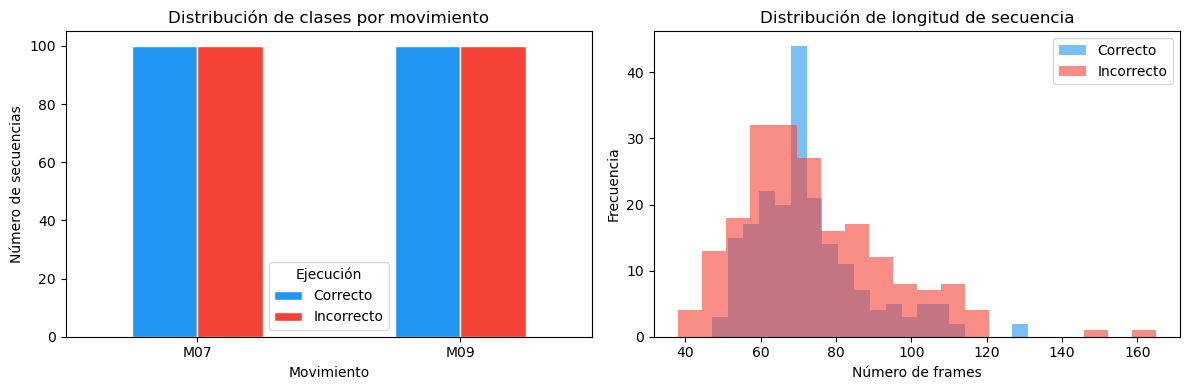

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de clases
color_map = {0: '#2196F3', 1: '#F44336'}
label_names = {0: 'Correcto', 1: 'Incorrecto'}
counts = df.groupby(['movement_id', 'label']).size().reset_index(name='n')
pivot = counts.pivot(index='movement_id', columns='label', values='n').fillna(0)
pivot.columns = [label_names[c] for c in pivot.columns]
pivot.index = [f'M{i:02d}' for i in pivot.index]
pivot.plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Distribución de clases por movimiento')
axes[0].set_xlabel('Movimiento')
axes[0].set_ylabel('Número de secuencias')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Ejecución')

# Distribución de frames
for lbl, name in label_names.items():
    subset = df[df.label == lbl]['n_frames']
    axes[1].hist(subset, bins=20, alpha=0.6, label=name, color=color_map[lbl])
axes[1].set_title('Distribución de longitud de secuencia')
axes[1].set_xlabel('Número de frames')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4 · Preparación de datos para el modelo

In [9]:
X = df[feat_cols].values.astype(np.float32)
y = df['label'].values.astype(int)
groups = df['subject_id'].values     # Usado en Leave-One-Subject-Out
movement = df['movement_id'].values

# Reemplaza NaN / Inf que puedan existir por 0
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}  →  {np.bincount(y)} ({np.bincount(y)/len(y)*100} %)')

X shape: (400, 726)
y shape: (400,)  →  [200 200] ([50. 50.] %)


## 5 · Modelo: RandomForestClassifier + class_weight

### 5.1 · Definición del pipeline

In [10]:
# ── Hiperparámetros base ─────────────────────────────────────────────────
rf_params = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features='sqrt',
    class_weight='balanced',   # Pondera proporcionalmente al desbalance
    n_jobs=-1,
    random_state=RANDOM_STATE,
    oob_score=True,            # Evaluación out-of-bag como sanity check
)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(**rf_params)),
])

print('Pipeline creado:')
print(clf)

Pipeline creado:
Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, min_samples_split=4,
                                        n_estimators=300, n_jobs=-1,
                                        oob_score=True, random_state=42))])


### 5.2 · Validación cruzada Leave-One-Subject-Out (LOSO)

Cada fold excluye **un sujeto completo** del entrenamiento → mide generalización real  
a usuarios nuevos (crítico para un sistema de rehabilitación).

In [11]:
logo = LeaveOneGroupOut()

print('Generando predicciones LOSO (puede tardar ~1-2 min) …')
y_pred_loso = cross_val_predict(
    clf, X, y,
    groups=groups,
    cv=logo,
    method='predict',
    n_jobs=-1,
)

y_proba_loso = cross_val_predict(
    clf, X, y,
    groups=groups,
    cv=logo,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]   # Probabilidad de clase INCORRECTA

print('✅ Validación cruzada LOSO completada.')

Generando predicciones LOSO (puede tardar ~1-2 min) …
✅ Validación cruzada LOSO completada.


### 5.3 · Reporte de métricas LOSO

In [12]:
print('=== Reporte de clasificación — LOSO ===')
print(classification_report(
    y, y_pred_loso,
    target_names=['Correcto (0)', 'Incorrecto (1)'],
    digits=4,
))

recall_inc = recall_score(y, y_pred_loso, pos_label=1)
f1_inc     = f1_score(y, y_pred_loso, pos_label=1)
try:
    auc = roc_auc_score(y, y_proba_loso)
except Exception:
    auc = float('nan')

print(f'Recall  Incorrecto : {recall_inc:.4f}')
print(f'F1      Incorrecto : {f1_inc:.4f}')
print(f'ROC-AUC            : {auc:.4f}')

=== Reporte de clasificación — LOSO ===
                precision    recall  f1-score   support

  Correcto (0)     0.8931    0.7100    0.7911       200
Incorrecto (1)     0.7593    0.9150    0.8299       200

      accuracy                         0.8125       400
     macro avg     0.8262    0.8125    0.8105       400
  weighted avg     0.8262    0.8125    0.8105       400

Recall  Incorrecto : 0.9150
F1      Incorrecto : 0.8299
ROC-AUC            : 0.9274


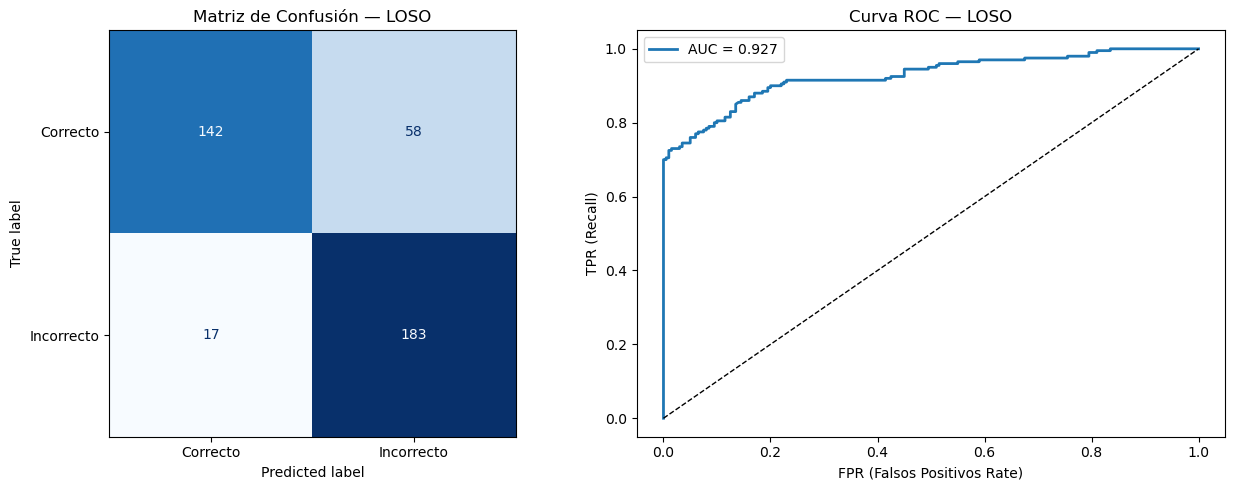

In [13]:
# ── Matriz de confusión LOSO ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y, y_pred_loso)
disp = ConfusionMatrixDisplay(cm, display_labels=['Correcto', 'Incorrecto'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión — LOSO')

# Curva ROC
if not math.isnan(auc):
    fpr, tpr, _ = roc_curve(y, y_proba_loso)
    axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('FPR (Falsos Positivos Rate)')
    axes[1].set_ylabel('TPR (Recall)')
    axes[1].set_title('Curva ROC — LOSO')
    axes[1].legend()

plt.tight_layout()
plt.show()

### 5.4 · Ajuste del umbral de decisión

El umbral por defecto es 0.5. Reduciéndolo aumentamos la sensibilidad (recall) de  
la clase **Incorrecto**, a costa de más falsos positivos en **Correcto**.

In [14]:
precisions, recalls, thresholds = precision_recall_curve(y, y_proba_loso, pos_label=1)

# Calcula F1 para cada umbral
f1s = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0.0
)

# Umbral que maximiza F1 de la clase Incorrecto
best_thresh_idx = np.argmax(f1s)
BEST_THRESHOLD  = float(thresholds[best_thresh_idx])

# Umbral agresivo: recall >= 0.90
recall_90_idx = np.where(recalls[:-1] >= 0.90)[0]
THRESHOLD_90 = float(thresholds[recall_90_idx[-1]]) if len(recall_90_idx) else BEST_THRESHOLD

print(f'Umbral óptimo (max F1) : {BEST_THRESHOLD:.3f}')
print(f'Umbral alta recall ≥90%: {THRESHOLD_90:.3f}')

# Aplica el umbral de alta recall al resultado LOSO
y_pred_t90 = (y_proba_loso >= THRESHOLD_90).astype(int)
print()
print(f'=== Reporte con umbral {THRESHOLD_90:.2f} (recall ≥90%) ===')
print(classification_report(
    y, y_pred_t90,
    target_names=['Correcto (0)', 'Incorrecto (1)'],
    digits=4,
))

Umbral óptimo (max F1) : 0.544
Umbral alta recall ≥90%: 0.535

=== Reporte con umbral 0.54 (recall ≥90%) ===
                precision    recall  f1-score   support

  Correcto (0)     0.8889    0.8000    0.8421       200
Incorrecto (1)     0.8182    0.9000    0.8571       200

      accuracy                         0.8500       400
     macro avg     0.8535    0.8500    0.8496       400
  weighted avg     0.8535    0.8500    0.8496       400



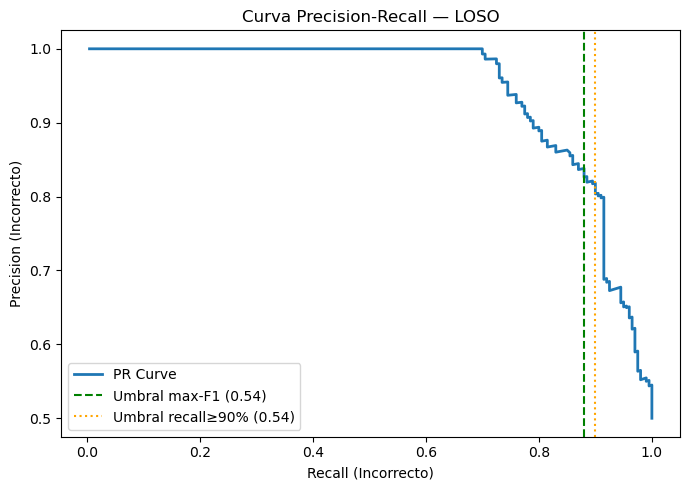

In [15]:
# Curva Precision-Recall
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls[:-1], precisions[:-1], lw=2, label='PR Curve')
ax.axvline(recalls[best_thresh_idx], ls='--', color='green',
           label=f'Umbral max-F1 ({BEST_THRESHOLD:.2f})')
ax.axvline(recalls[recall_90_idx[-1]] if len(recall_90_idx) else 0,
           ls=':', color='orange', label=f'Umbral recall≥90% ({THRESHOLD_90:.2f})')
ax.set_xlabel('Recall (Incorrecto)')
ax.set_ylabel('Precision (Incorrecto)')
ax.set_title('Curva Precision-Recall — LOSO')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 · Análisis por sujeto

In [16]:
results_by_subject = []
for subj_id in sorted(df.subject_id.unique()):
    mask = groups == subj_id
    if mask.sum() == 0:
        continue
    yi_true = y[mask]
    yi_pred = y_pred_loso[mask]
    yi_t90  = y_pred_t90[mask]
    try:
        r_default = recall_score(yi_true, yi_pred, pos_label=1, zero_division=0)
        r_t90     = recall_score(yi_true, yi_t90,  pos_label=1, zero_division=0)
        f1_def    = f1_score(yi_true, yi_pred, pos_label=1, zero_division=0)
    except Exception:
        r_default = r_t90 = f1_def = float('nan')
    results_by_subject.append({
        'Sujeto': f's{subj_id:02d}',
        'N_muestras': int(mask.sum()),
        'Recall_default': round(r_default, 4),
        'Recall_t90': round(r_t90, 4),
        'F1_default': round(f1_def, 4),
    })

res_df = pd.DataFrame(results_by_subject)
print(res_df.to_string(index=False))

Sujeto  N_muestras  Recall_default  Recall_t90  F1_default
   s01          40            0.75        0.75      0.7692
   s02          40            1.00        1.00      0.8511
   s03          40            0.70        0.70      0.8235
   s04          40            0.95        0.95      0.8261
   s05          40            0.95        0.95      0.9744
   s06          40            0.85        0.85      0.7907
   s07          40            1.00        0.95      0.6780
   s08          40            0.95        0.90      0.9744
   s09          40            1.00        1.00      1.0000
   s10          40            1.00        0.95      0.7273


## 6 · Entrenamiento del modelo final

Tras confirmar métricas LOSO satisfactorias, entrenamos con **todos los datos** para obtener  
el modelo más robusto posible para producción.

In [17]:
print('Entrenando modelo final con todos los datos …')
clf.fit(X, y)

oob = clf.named_steps['rf'].oob_score_
print(f'✅ Modelo entrenado.  OOB score: {oob:.4f}')

Entrenando modelo final con todos los datos …
✅ Modelo entrenado.  OOB score: 0.9425


### 6.1 · Importancia de features (top 20)

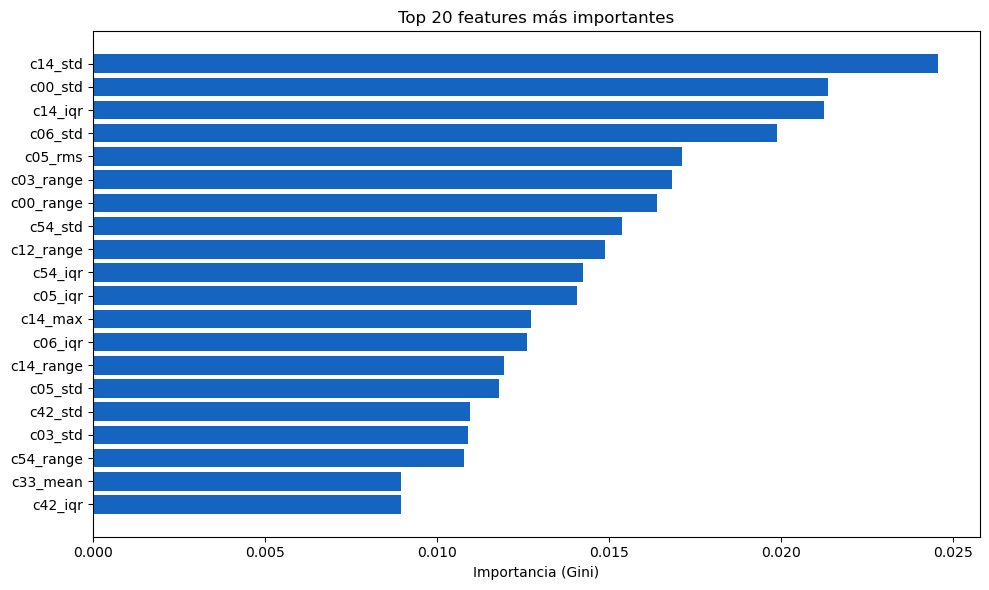

In [18]:
importances = clf.named_steps['rf'].feature_importances_

STAT_NAMES = ['mean', 'std', 'min', 'max', 'range', 'median', 'iqr', 'rms', 'skew', 'kurt', 'mad']
feature_labels = [
    f'c{col_i:02d}_{stat}'
    for col_i in range(N_COLS_KINECT)
    for stat in STAT_NAMES
]

top_k = 20
top_idx = np.argsort(importances)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [feature_labels[i] for i in top_idx][::-1],
    importances[top_idx][::-1],
    color='#1565C0'
)
ax.set_xlabel('Importancia (Gini)')
ax.set_title(f'Top {top_k} features más importantes')
plt.tight_layout()
plt.show()

## 7 · Exportación del modelo

In [19]:
movements_str = '_'.join(f'm{i:02d}' for i in sorted(MOVEMENT_IDS))
MODEL_PATH = BASE_DIR / f'modelo_rf_{movements_str}.pkl'

model_bundle = {
    'pipeline':       clf,
    'threshold':      THRESHOLD_90,   # Umbral calibrado para recall ≥ 90%
    'movement_ids':   MOVEMENT_IDS,
    'movement_names': {i: MOVEMENT_NAMES[i] for i in MOVEMENT_IDS},
    'feat_cols':      feat_cols,
    'n_feat_per_col': N_FEATURES_PER_COL,
    'n_cols_kinect':  N_COLS_KINECT,
    'dataset_source': DATA_SOURCE,
    'classes':        {0: 'Correcto', 1: 'Incorrecto'},
}

joblib.dump(model_bundle, MODEL_PATH)
print(f'✅ Modelo exportado → {MODEL_PATH}')

✅ Modelo exportado → C:\Users\marco\notebooks\modelo_rehabilitacion\modelo_rf_m07_m09.pkl


## 8 · Función de inferencia para JSON del móvil

El sistema recibirá JSONs con `puntos_clave` provenientes de MediaPipe (MoveNet) desde  
la cámara del Samsung Tab S3 (Samsung Galaxy Tab S3).  
Esta función transforma ese JSON en el vector de features y produce la predicción.

### 8.1 · Mapeo de joints: MediaPipe → UI-PRMD

| Joint MediaPipe/JSON | Equivalente en UI-PRMD (Kinect) |
|----------------------|----------------------------------|
| nariz (`nose`)        | SpineShoulder (proxy) |
| hombro_d              | ShoulderRight |
| codo_d                | ElbowRight |
| muñeca_d              | WristRight |

In [20]:
# Carga el bundle desde disco para demostrar un flujo de inferencia independiente
bundle = joblib.load(MODEL_PATH)
model_pipeline: Pipeline = bundle['pipeline']
DECISION_THRESHOLD: float = bundle['threshold']

# Nombres de joints esperados en el JSON del móvil
JOINT_KEYS = [
    'nariz', 'hombro_d', 'codo_d', 'muñeca_d',
    # Extiende con más joints conforme se integren en la app
]


def json_to_feature_matrix(puntos_clave: dict) -> np.ndarray:
    """Convierte un dict `puntos_clave` del JSON móvil en una matriz (1 x n_joints*3).

    Cada joint contribuye con (x, y, z). Los joints ausentes se rellenan con 0.0.
    La función está diseñada para llamarse frame a frame durante la ejecución
    del ejercicio para construir la serie temporal.

    Parámetros
    ----------
    puntos_clave : dict  — sección 'puntos_clave' del JSON sin metadata

    Retorna
    -------
    np.ndarray de forma (1, n_joints * 3)
    """
    row = []
    for jk in JOINT_KEYS:
        joint = puntos_clave.get(jk, {})  # Puede no existir (oclusión)
        row.extend([
            float(joint.get('x', 0.0)),
            float(joint.get('y', 0.0)),
            float(joint.get('z', 0.0)),
        ])
    return np.array(row, dtype=np.float32).reshape(1, -1)


def inferir_calidad(
    frames_json: list[dict],
    movement_id: int,
) -> dict:
    """Clasifica la calidad de ejecución de UN ejercicio a partir de una secuencia de frames JSON.

    Parámetros
    ----------
    frames_json  : lista de dicts, cada uno con clave 'puntos_clave'.
                   Corresponde a todos los frames capturados en una repetición.
    movement_id  : ID del ejercicio (7 o 9).

    Retorna
    -------
    dict con:
      - 'label'          : 0=Correcto, 1=Incorrecto
      - 'etiqueta'       : 'Correcto' | 'Incorrecto'
      - 'probabilidad'   : probabilidad de ejecución INCORRECTA
      - 'confianza'      : probabilidad de la clase predicha
      - 'feedback'       : mensaje de retroalimentación para el paciente
      - 'movement_id'    : ejercicio evaluado
    """
    if movement_id not in bundle['movement_ids']:
        raise ValueError(
            f'Movimiento m{movement_id:02d} no soportado. Entrena con ese ID primero.'
        )

    if len(frames_json) < 2:
        raise ValueError('Se necesitan al menos 2 frames para calcular características.')

    # Construye la matriz de series temporal a partir de los frames
    frames_matrix = np.vstack([
        json_to_feature_matrix(f.get('puntos_clave', f))
        for f in frames_json
    ])

    # Si el modelo fue entrenado con Angles (66 cols) y recibimos < 66 cols,
    # se rellena con ceros para mantener consistencia dimensional.
    target_cols = bundle['n_cols_kinect']
    if frames_matrix.shape[1] < target_cols:
        pad = np.zeros((frames_matrix.shape[0], target_cols - frames_matrix.shape[1]),
                       dtype=np.float32)
        frames_matrix = np.hstack([frames_matrix, pad])
    elif frames_matrix.shape[1] > target_cols:
        frames_matrix = frames_matrix[:, :target_cols]

    # Extrae features de la secuencia
    fv = extract_features(frames_matrix).reshape(1, -1)
    fv = np.nan_to_num(fv, nan=0.0, posinf=0.0, neginf=0.0)

    proba_inc = float(model_pipeline.predict_proba(fv)[0][1])
    label = int(proba_inc >= DECISION_THRESHOLD)

    # Mensajes de feedback básicos (extensibles con LLM / reglas)
    feedback_templates = {
        7: {
            0: '¡Buena ejecución! Mantén el codo pegado al cuerpo durante la rotación.',
            1: 'Se detectó una ejecución irregular. Verifica que el codo permanezca '
               'pegado al torso y la rotación sea controlada.',
        },
        9: {
            0: '¡Excelente abducción! Mantén el brazo a la altura del hombro.',
            1: 'Se detectó una ejecución irregular. Asegúrate de elevar el brazo '
               'hasta la horizontal y de no compensar con el tronco.',
        },
    }
    feedback = feedback_templates.get(movement_id, {}).get(
        label,
        '¡Bien hecho!' if label == 0 else 'Revisa la técnica del ejercicio.'
    )

    return {
        'label':        label,
        'etiqueta':     'Incorrecto' if label else 'Correcto',
        'probabilidad': round(proba_inc, 4),
        'confianza':    round(proba_inc if label else 1 - proba_inc, 4),
        'feedback':     feedback,
        'movement_id':  movement_id,
    }


print('Función inferir_calidad() definida.')

Función inferir_calidad() definida.


### 8.2 · Demo de inferencia con el JSON de ejemplo

In [21]:
# JSON de ejemplo recibido del Samsung Tab S3
json_ejemplo = {
    'metadatos': {
        'dispositivo': 'Samsung Tab S3',
        'orientacion': 'Portrait',
        'pantalla_px': {'ancho': 1536, 'alto': 2048},
        'timestamp_ms': 1710584200123
    },
    'puntos_clave': {
        'nariz':     {'x': 0.50, 'y': 0.20, 'z': -0.15},
        'hombro_d':  {'x': 0.40, 'y': 0.35, 'z': -0.05},
        'codo_d':    {'x': 0.35, 'y': 0.50, 'z': -0.08},
        'muñeca_d':  {'x': 0.30, 'y': 0.65, 'z': -0.12},
    }
}

# Simula una repetición: 30 frames con pequeñas variaciones gaussianas
rng = np.random.default_rng(seed=0)
frames_simulados = []
for _ in range(30):
    frame_pk = {}
    for jname, coords in json_ejemplo['puntos_clave'].items():
        frame_pk[jname] = {
            k: v + rng.normal(0, 0.02) for k, v in coords.items()
        }
    frames_simulados.append({'puntos_clave': frame_pk})

# Inferencia
resultado = inferir_calidad(frames_simulados, movement_id=7)

print('=== Resultado de inferencia ===')
for k, v in resultado.items():
    print(f'  {k:15s}: {v}')

=== Resultado de inferencia ===
  label          : 1
  etiqueta       : Incorrecto
  probabilidad   : 0.7188
  confianza      : 0.7188
  feedback       : Se detectó una ejecución irregular. Verifica que el codo permanezca pegado al torso y la rotación sea controlada.
  movement_id    : 7


### 8.3 · Inferencia desde JSON completo (un solo frame guardado)

Si la app solo envía **un frame** (snapshot), la inferencia también funciona;  
en ese caso la serie temporal tendrá un solo punto y se replican features básicos.

In [22]:
def inferir_desde_json_crudo(json_str: str, movement_id: int, n_frames_simulados: int = 5) -> dict:
    """Acepta directamente el JSON crudo (string o dict) del móvil.

    Si el JSON contiene un único frame, lo replica `n_frames_simulados` veces  
    para cumplir el mínimo requerido.
    """
    if isinstance(json_str, str):
        payload = json.loads(json_str)
    else:
        payload = json_str

    puntos = payload.get('puntos_clave', {})

    # Replica el frame para tener una serie mínima
    frames = [{'puntos_clave': puntos}] * max(n_frames_simulados, 2)

    return inferir_calidad(frames, movement_id=movement_id)


resultado_raw = inferir_desde_json_crudo(json_ejemplo, movement_id=9)
print('Inferencia desde JSON crudo (m09 — Shoulder Abduction):')
print(json.dumps(resultado_raw, ensure_ascii=False, indent=2))

Inferencia desde JSON crudo (m09 — Shoulder Abduction):
{
  "label": 1,
  "etiqueta": "Incorrecto",
  "probabilidad": 0.7204,
  "confianza": 0.7204,
  "feedback": "Se detectó una ejecución irregular. Asegúrate de elevar el brazo hasta la horizontal y de no compensar con el tronco.",
  "movement_id": 9
}


## 9 · Resumen final de métricas

Esta celda consolida los resultados para incluir en el reporte del proyecto.

In [23]:
from sklearn.metrics import accuracy_score, precision_score

metrics_summary = {
    'Ejercicios entrenados': ', '.join(f"m{i:02d}" for i in MOVEMENT_IDS),
    'Fuente de datos': DATA_SOURCE,
    'Total de muestras': len(df),
    'Muestras correctas': int((y == 0).sum()),
    'Muestras incorrectas': int((y == 1).sum()),
    'Dimensión features': X.shape[1],
    '--- LOSO (umbral 0.5) ---': '---',
    'Accuracy': round(accuracy_score(y, y_pred_loso), 4),
    'Precision Incorrecto': round(precision_score(y, y_pred_loso, pos_label=1, zero_division=0), 4),
    'Recall Incorrecto': round(recall_score(y, y_pred_loso, pos_label=1, zero_division=0), 4),
    'F1 Incorrecto': round(f1_score(y, y_pred_loso, pos_label=1, zero_division=0), 4),
    'ROC-AUC': round(auc, 4),
    f'--- LOSO (umbral {THRESHOLD_90:.2f}, recall≥90%) ---': '---',
    'Recall Incorrecto (umbral ajustado)': round(recall_score(y, y_pred_t90, pos_label=1, zero_division=0), 4),
    'Precision Incorrecto (umbral ajustado)': round(precision_score(y, y_pred_t90, pos_label=1, zero_division=0), 4),
    'F1 Incorrecto (umbral ajustado)': round(f1_score(y, y_pred_t90, pos_label=1, zero_division=0), 4),
    'OOB score (modelo final)': round(oob, 4),
    'Umbral empleado en producción': round(THRESHOLD_90, 4),
    'Modelo exportado': str(MODEL_PATH.name),
}

print('╔══════════════════════════════════════════════════════════════╗')
print('║              RESUMEN DE ENTRENAMIENTO / EVALUACIÓN           ║')
print('╠══════════════════════════════════════════════════════════════╣')
for k, v in metrics_summary.items():
    print(f'║  {k:<40} {str(v):<17} ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║              RESUMEN DE ENTRENAMIENTO / EVALUACIÓN           ║
╠══════════════════════════════════════════════════════════════╣
║  Ejercicios entrenados                    m07, m09          ║
║  Fuente de datos                          Angles            ║
║  Total de muestras                        400               ║
║  Muestras correctas                       200               ║
║  Muestras incorrectas                     200               ║
║  Dimensión features                       726               ║
║  --- LOSO (umbral 0.5) ---                ---               ║
║  Accuracy                                 0.8125            ║
║  Precision Incorrecto                     0.7593            ║
║  Recall Incorrecto                        0.915             ║
║  F1 Incorrecto                            0.8299            ║
║  ROC-AUC                                  0.9274            ║
║  --- LOSO (umbral 0.54, recall≥90%)

---

## Notas de uso

### Cargar el modelo en producción
```python
import joblib
bundle = joblib.load('modelo_rf_m07_m09.pkl')
pipeline = bundle['pipeline']
threshold = bundle['threshold']   # ~0.30-0.40 para recall ≥ 90%
```

### Flujo de inferencia en tiempo real
```
Cámara móvil
  → MoveNet / MediaPipe → JSON con `puntos_clave`
  → inferir_desde_json_crudo(json, movement_id=7)
  → {'label': 1, 'etiqueta': 'Incorrecto', 'feedback': '...', 'probabilidad': 0.78}
  → LLM / reglas → Retroalimentación al paciente
```

### Para agregar más ejercicios
```python
MOVEMENT_IDS = [1, 7, 9]   # Elbow Flexion + Shoulder Rotation + Abduction
# Vuelve a ejecutar todas las celdas
```

### Próximos pasos
1. **Más features**: velocidad angular, simetría bilateral, DTW con templates de referencia.
2. **Modelo por ejercicio**: entrenar un RF separado por `movement_id` para mayor especialización.
3. **Datos de app móvil**: calibrar la transformación de coordenadas MoveNet → escala Kinect.
4. **Feedback granular**: identificar *qué* articulación tiene el error usando feature importance + SHAP.